## Libraries

In [1]:
import yfinance as yf
import os
import pandas as pd

## ETL & Exploratory Data Analysis (EDA)

### Extract

In [2]:
PETR4_ticker = yf.Ticker("PETR4.SA")
PETR4 = PETR4_ticker.history(period="max", start="2000-01-01", interval="1d")

Visualizar a tabela - Inicio da Análise Exploratória:

In [3]:
PETR4.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2000-01-03 00:00:00-02:00,1.105646,1.105646,1.105646,1.105646,35389440000,0.0,0.0
2000-01-04 00:00:00-02:00,1.044483,1.044483,1.044483,1.044483,28861440000,0.0,0.0
2000-01-05 00:00:00-02:00,1.033944,1.033944,1.033944,1.033944,43033600000,0.0,0.0
2000-01-06 00:00:00-02:00,1.030368,1.030368,1.030368,1.030368,34055680000,0.0,0.0
2000-01-07 00:00:00-02:00,1.035073,1.035073,1.035073,1.035073,20912640000,0.0,0.0


### Transform

In [ ]:
# Passar os dados em cache para CSV
PETR4.to_csv("data/PETR4.SA2.csv")

In [ ]:
# Declarar o CSV como data frame 
df = pd.read_csv('data/PETR4.SA2.csv')
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2000-01-03 00:00:00-02:00,1.105646,1.105646,1.105646,1.105646,35389440000,0.0,0.0
1,2000-01-04 00:00:00-02:00,1.044483,1.044483,1.044483,1.044483,28861440000,0.0,0.0
2,2000-01-05 00:00:00-02:00,1.033944,1.033944,1.033944,1.033944,43033600000,0.0,0.0
3,2000-01-06 00:00:00-02:00,1.030368,1.030368,1.030368,1.030368,34055680000,0.0,0.0
4,2000-01-07 00:00:00-02:00,1.035073,1.035073,1.035073,1.035073,20912640000,0.0,0.0


In [16]:
# Verificar se há dados faltantes
df[df.isna().any(axis=1)]

# Remover as linhas com células em branco
df = df.dropna()

# Converter a coluna "Date" para o formato de data
df["Date"] = pd.to_datetime(df["Date"], utc=True).dt.tz_localize(None)
df["Date"] = df["Date"].dt.date

# Declarar a variável "prices" com os preços de fechamento da moeda
prices = df["Close"]

### Load

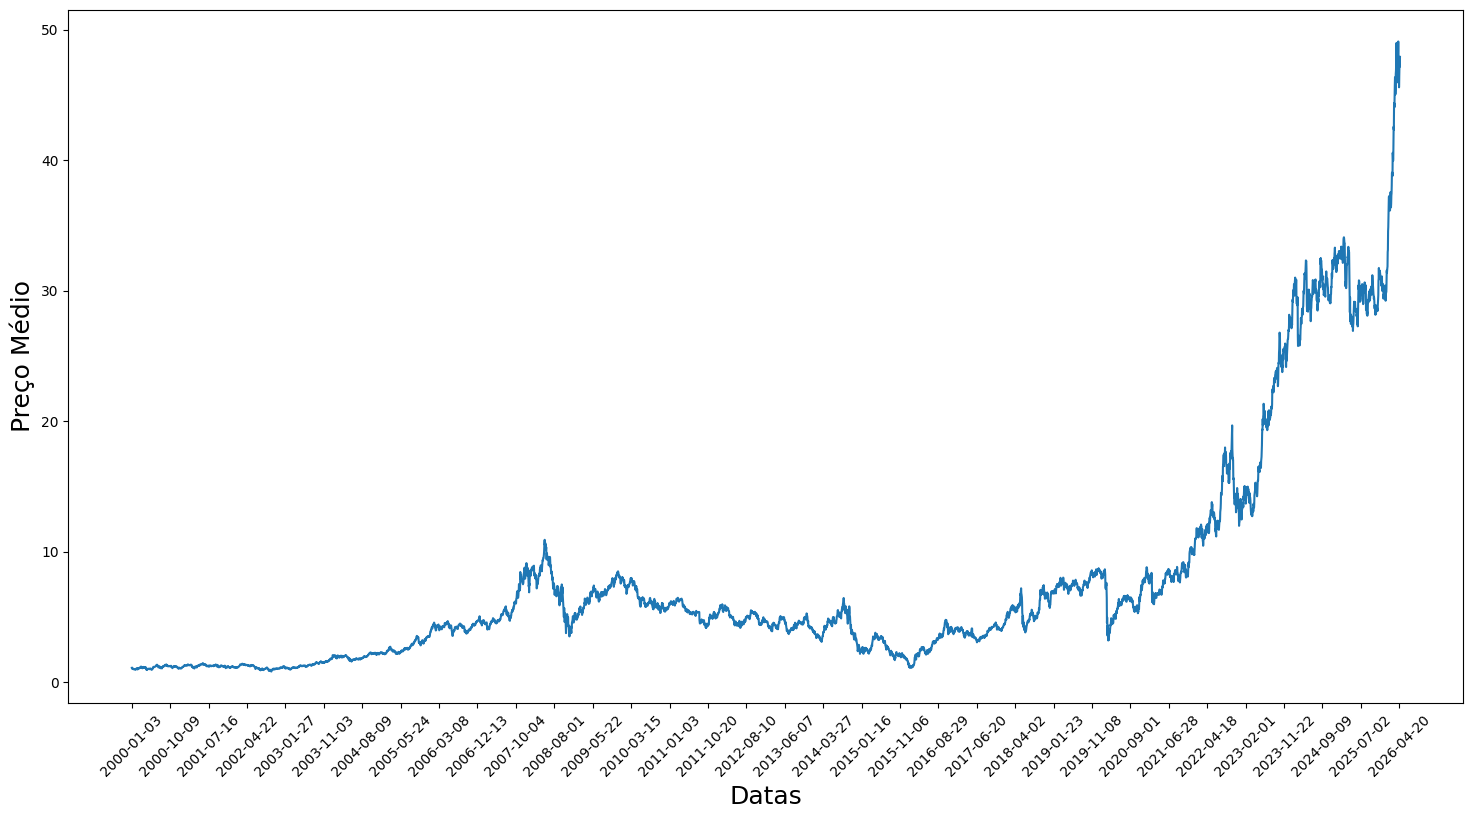

In [ ]:
# Primeira visualização dos dados

import matplotlib.pyplot as plt

plt.figure(figsize = (18,9))
plt.plot(df['Close'])
plt.xticks(range(0,df.shape[0],200), df['Date'].loc[::200], rotation=45)
plt.xlabel('Datas', fontsize=18)
plt.ylabel('Preço Médio', fontsize=18)
plt.show()